# Support Vector Classifier (SVC)

In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [195]:
from sklearn.datasets import make_classification
X , y = make_classification(n_samples=1000 , n_features=2 , 
                n_classes=2 , n_redundant=0 ,
                n_clusters_per_class=2
                ,   n_informative=2  )

In [196]:
df = pd.DataFrame(X , y)

In [197]:
df.shape

(1000, 2)

In [198]:
df.head()

,0,1
0,0.241100,3.279728
1,0.934051,-0.921927
1,1.205487,1.228092
1,0.819942,0.800936
0,-1.006110,-0.958575


<Axes: xlabel='0', ylabel='1'>

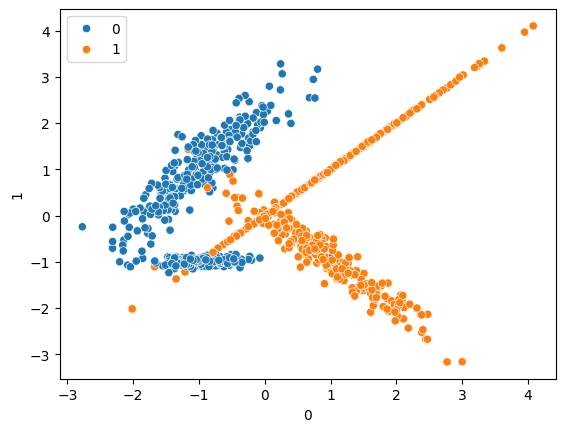

In [199]:
sns.scatterplot(x=df[0], y=df[1], hue=y)

## Train Test Split

In [200]:
from sklearn.model_selection import train_test_split
X_train , X_test  , y_train , y_test = train_test_split(X , y , test_size=0.25 , random_state=42)

In [201]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')

In [202]:
svc.fit(X_train , y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Prediction

In [203]:
y_pred = svc.predict(X_test)

In [204]:
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score

In [205]:
# Score 
score = accuracy_score(y_test , y_pred)
print("Score  :" , score)

Score  : 0.944


In [206]:
# Confussion Matrix
cm = confusion_matrix(y_test , y_pred)
print("Confussion Matrix :\n " , cm )

Confussion Matrix :
  [[118   3]
 [ 11 118]]


In [207]:
# Classfication Report
cr = classification_report(y_test , y_pred)
print("Classification Report : \n" , cr)

Classification Report : 
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       121
           1       0.98      0.91      0.94       129

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.95      0.94      0.94       250



## Using RBF Kernel 

In [208]:
rbf = SVC(kernel='rbf')
rbf.fit(X_train , y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [209]:
y_pred = rbf.predict(X_test)

In [210]:
print(accuracy_score(y_test , y_pred))

0.984


### Observation
1 . Using RBF Kernel instead of Linear The model increase the accuracy score

    In Linear Kernel : 0.94

    In RBF Kernel : 0.95

In [211]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       121
           1       1.00      0.97      0.98       129

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250



## Visualize the Decission Boundary and Marginal line

In [212]:
w = svc.coef_[0]
w

array([ 2.54532013, -0.5476338 ])

In [213]:
b = svc.intercept_[0]
b

np.float64(0.4200021891525046)

In [214]:
# Create Line space
X_min , X_max = df[0].min()-1 , df[0].max()+1 
xx = np.linspace(X_min , X_max , 200)

In [215]:
# db = decission Boundry
db = yy = -(w[0] * xx + b) / w[1]

In [216]:
# Margins
yy_margin_pos = -(w[0] * xx + b - 1) / w[1]
yy_margin_neg = -(w[0] * xx + b + 1) / w[1]

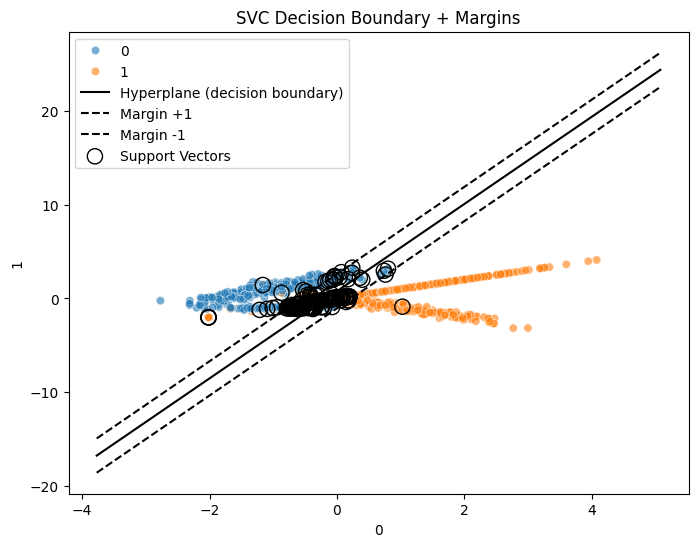

In [217]:
# Plot
plt.figure(figsize=(8,6))
# Original data
sns.scatterplot(x=df[0], y=df[1], hue=y, alpha=0.6)
# Decision boundary
plt.plot(xx, yy, 'k-', label='Hyperplane (decision boundary)')
# Margins
plt.plot(xx, yy_margin_pos, 'k--', label='Margin +1')
plt.plot(xx, yy_margin_neg, 'k--', label='Margin -1')
# Support vectors
plt.scatter(svc.support_vectors_[:, 0],
            svc.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='black',
            label='Support Vectors')

plt.legend()
plt.title("SVC Decision Boundary + Margins")
plt.show()

## HyperParameter Tunning

In [218]:
from sklearn.model_selection import GridSearchCV
# Defining Parameter Range
param_grid = {
    'C' : [0.1 , 1 , 10 , 100 , 1000] ,
    'gamma' : [1 , 0.1 , 0.01 , 0.001 , 0.0001] ,
    'kernel' : ['rbf' , 'polynomial' , 'linear' , 'sigmoid']
}

In [219]:
grid = GridSearchCV(svc , param_grid , cv=5 , verbose=3 , refit=True)

In [220]:
grid.fit(X_train , y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.993 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.987 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.980 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.967 total time=   0.0s
[CV 1/5] END ...C=0.1, gamma=1, kernel=polynomial;, score=nan total time=   0.0s
[CV 2/5] END ...C=0.1, gamma=1, kernel=polynomial;, score=nan total time=   0.0s
[CV 3/5] END ...C=0.1, gamma=1, kernel=polynomial;, score=nan total time=   0.0s
[CV 4/5] END ...C=0.1, gamma=1, kernel=polynomial;, score=nan total time=   0.0s
[CV 5/5] END ...C=0.1, gamma=1, kernel=polynomial;, score=nan total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.940 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linea

c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
125 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
125 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\base.py", line 492, in _validate_params
    validate_parameter_const

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='linear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'polynomial', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also 

In [221]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [222]:
grid.best_score_

np.float64(0.9879999999999999)

In [223]:
print(grid.best_estimator_)

SVC(C=10, gamma=1)


In [224]:
y_predict = grid.predict(X_test)

In [225]:
accuracy_score(y_test , y_predict)

0.984

In [226]:
confusion_matrix(y_test , y_pred)

array([[121,   0],
       [  4, 125]])

In [227]:
print(classification_report(y_test , y_predict))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       121
           1       1.00      0.97      0.98       129

    accuracy                           0.98       250
   macro avg       0.98      0.98      0.98       250
weighted avg       0.98      0.98      0.98       250

